## Train Feline

✅ Feline dataset loaded - Classes: ['erythrocyte', 'reticulocyte']
Train samples: 2353, Val samples: 589


Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth
100%|██████████| 528M/528M [00:02<00:00, 210MB/s] 



Epoch 1/20
--------------------------------------------------


Train - Loss: 0.3215, Acc: 86.66%
Val   - Loss: 0.1551, Acc: 94.06%
✅ New best validation accuracy: 94.06%

Epoch 2/20
--------------------------------------------------


Train - Loss: 0.1342, Acc: 95.16%
Val   - Loss: 0.4337, Acc: 86.08%
Patience: 1/5

Epoch 3/20
--------------------------------------------------


Train - Loss: 0.0858, Acc: 96.81%
Val   - Loss: 0.1867, Acc: 93.38%
Patience: 2/5

Epoch 4/20
--------------------------------------------------


Train - Loss: 0.0572, Acc: 98.47%
Val   - Loss: 0.2083, Acc: 92.53%
Patience: 3/5

Epoch 5/20
--------------------------------------------------


Train - Loss: 0.0592, Acc: 97.79%
Val   - Loss: 0.2373, Acc: 92.87%
Patience: 4/5

Epoch 6/20
--------------------------------------------------


Train - Loss: 0.0341, Acc: 98.81%
Val   - Loss: 0.2988, Acc: 92.02%
Patience: 5/5
🛑 Early stopping triggered at epoch 6

🎉 Training completed! Best validation accuracy: 94.06%


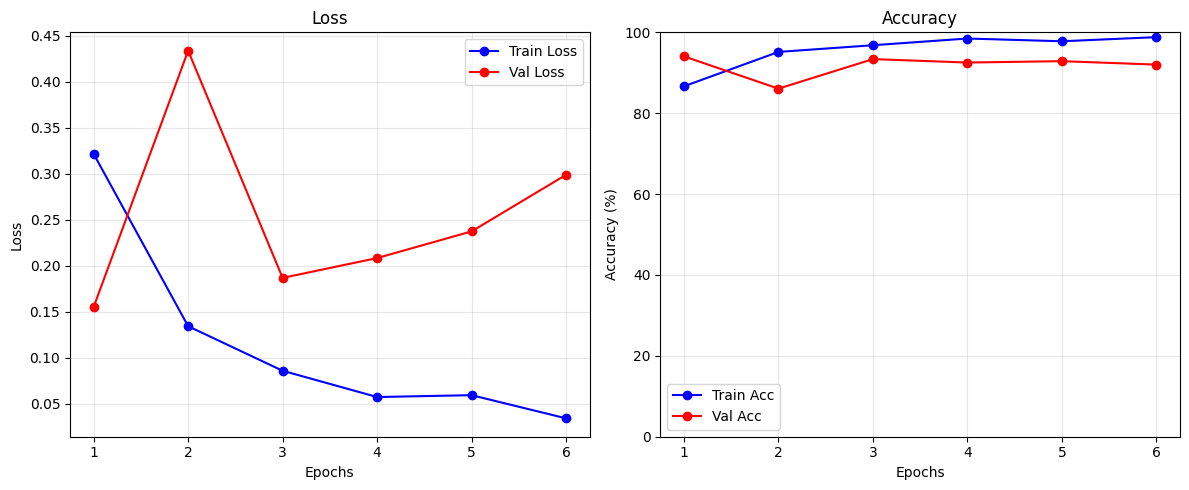

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# Check the device beingf used
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42); np.random.seed(42); random.seed(42)

CONFIG = {
    "FELINE_DIR": Path("/kaggle/input/cenparmi-human-dataset-downloaded/cenparmi_dataset/felineAlldata"),
    "OUTPUT_DIR": Path("outputs"),
    "IMG_SIZE": 224,
    "BATCH_SIZE": 32,
    "FELINE_EPOCHS": 20,
    "LEARNING_RATE": 1e-4,
    "PATIENCE": 5
}
CONFIG["OUTPUT_DIR"].mkdir(exist_ok=True, parents=True) #Check if the output directory exists

# Perform Augmentation on the Train Set
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Resize and Normalize the Validation Set
val_transform = transforms.Compose([
    transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
    transforms.ToTensor(), #Converts the image from a PIL imagfe or NumPy array to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split the Feline Dataset
full_dataset = datasets.ImageFolder(CONFIG["FELINE_DIR"], transform=val_transform)
indices = list(range(len(full_dataset)))
labels = [full_dataset[i][1] for i in indices]

train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=labels, random_state=42)
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=CONFIG["BATCH_SIZE"], shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=4, pin_memory=True)
num_classes = len(full_dataset.classes)

print(f"✅ Feline dataset loaded - Classes: {full_dataset.classes}")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

# Define the VGG16 model to train and evaluate the Feline Dataset
class VGG16Model(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.backbone = models.vgg16_bn(weights=models.VGG16_BN_Weights.IMAGENET1K_V1 if pretrained else None) 
        in_features = self.backbone.classifier[-1].in_features # Replace the Classifier Layer
        self.backbone.classifier[-1] = nn.Linear(in_features, num_classes) # nn.Linear layer to match task’s num_classes.
        
    # Forward Pass
    def forward(self, x):
        return self.backbone(x)

model = VGG16Model(num_classes=num_classes, pretrained=True).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG["LEARNING_RATE"])

# Training
train_losses, train_accs, val_losses, val_accs = [], [], [], []
best_val_acc = 0
patience_counter = 0

for epoch in range(CONFIG["FELINE_EPOCHS"]):
    print(f"\nEpoch {epoch+1}/{CONFIG['FELINE_EPOCHS']}")
    print("-"*50)
    
    # Train
    model.train()
    total_loss, correct, total = 0, 0, 0
    for data, target in tqdm(train_loader, desc="Training", leave=False):
        data, target = data.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
    train_loss = total_loss / len(train_loader)
    train_acc = 100. * correct / total
    
    # Validate
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
    val_loss = total_loss / len(val_loader)
    val_acc = 100. * correct / total
    
    # Store metrics
    train_losses.append(train_loss); train_accs.append(train_acc)
    val_losses.append(val_loss); val_accs.append(val_acc)
    
    print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
    print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CONFIG["OUTPUT_DIR"] / "vgg16_feline_best.pth")
        patience_counter = 0
        print(f"✅ New best validation accuracy: {val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"Patience: {patience_counter}/{CONFIG['PATIENCE']}")
    
    if patience_counter >= CONFIG["PATIENCE"]:
        print(f"🛑 Early stopping triggered at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(torch.load(CONFIG["OUTPUT_DIR"] / "vgg16_feline_best.pth"))
print(f"\n🎉 Training completed! Best validation accuracy: {best_val_acc:.2f}%")

# --------------------------- PLOT HISTORY ---------------------------
epochs = range(1, len(train_losses)+1)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'bo-', label='Train Loss')
plt.plot(epochs, val_losses, 'ro-', label='Val Loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(epochs, train_accs, 'bo-', label='Train Acc')
plt.plot(epochs, val_accs, 'ro-', label='Val Acc')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0,100)
plt.tight_layout()
plt.show()


## KD: 3T 1S WITH AUGMENTAION

In [2]:
import os, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== CONFIG ======================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths - Updated to match your original config
FELINE_MODEL_PATH = Path("outputs/vgg16_feline_best.pth")  # Path to your trained feline model
HUMAN_IMG_PATH = "/kaggle/input/cenparmi-human-dataset-downloaded/cenparmi_dataset/human_data"
SAVE_ROOT = Path("outputs") / "kd_augmented"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

# Training schedule
EPOCHS_TEACHER = 5
EPOCHS_STUDENT = 8
BATCH_SIZE = 32
LR = 1e-4
WEIGHT_DECAY = 1e-4
ALPHA, TEMPERATURE = 0.5, 4.0
GRAD_CLIP_NORM = 2.0
VAL_FRAC, TEST_FRAC = 0.2, 0.2
NUM_WORKERS = 2
IMG_SIZE = 224

# ====================== VGG16 MODEL FROM YOUR CODE ======================
class VGG16Model(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.backbone = models.vgg16_bn(weights=models.VGG16_BN_Weights.IMAGENET1K_V1 if pretrained else None)
        in_features = self.backbone.classifier[-1].in_features
        self.backbone.classifier[-1] = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

# ====================== DATA ======================
mean_imnet = [0.485, 0.456, 0.406]
std_imnet = [0.229, 0.224, 0.225]

# Data transforms (matching your original transforms)
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])

# Build human dataset
human_base = datasets.ImageFolder(HUMAN_IMG_PATH, transform=None)
NUM_CLASSES = len(human_base.classes)

# ==================================================
# Four-way stratified split: Train / Val / Test / FSL_pool
# ==================================================
def stratified_split_4(base_ds, val_frac, test_frac, fsl_frac, seed=SEED):
    indices = list(range(len(base_ds)))
    labels = [base_ds[i][1] for i in indices]

    # First: split out test set
    tr_idx, te_idx = train_test_split(indices, test_size=test_frac,
                                      stratify=labels, random_state=seed)

    # Now split remaining into val and pool+train
    tr_labels = [base_ds[i][1] for i in tr_idx]
    tr_idx, va_idx = train_test_split(tr_idx, test_size=val_frac/(1-test_frac),
                                      stratify=tr_labels, random_state=seed)

    # Now split remaining into train and FSL_pool
    tr_labels2 = [base_ds[i][1] for i in tr_idx]
    tr_idx, fsl_idx = train_test_split(tr_idx, test_size=fsl_frac/(1-test_frac-val_frac),
                                       stratify=tr_labels2, random_state=seed)

    return tr_idx, va_idx, te_idx, fsl_idx

# Fractions must add up ≤ 1.0
VAL_FRAC, TEST_FRAC, FSL_FRAC = 0.2, 0.2, 0.2
h_tr_idx, h_va_idx, h_te_idx, h_fsl_idx = stratified_split_4(human_base, VAL_FRAC, TEST_FRAC, FSL_FRAC)

# Build datasets
human_train = Subset(datasets.ImageFolder(HUMAN_IMG_PATH, transform=train_tf), h_tr_idx)
human_val   = Subset(datasets.ImageFolder(HUMAN_IMG_PATH, transform=eval_tf), h_va_idx)
human_test  = Subset(datasets.ImageFolder(HUMAN_IMG_PATH, transform=eval_tf), h_te_idx)
human_fsl   = Subset(datasets.ImageFolder(HUMAN_IMG_PATH, transform=eval_tf), h_fsl_idx)

print("Human dataset sizes after split:")
print(" Train:", len(human_train), 
      " Val:", len(human_val), 
      " Test:", len(human_test), 
      " FSL_pool:", len(human_fsl),
      " Classes:", human_base.classes)

def make_loader(ds, shuffle=False):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True)

human_train_loader = make_loader(human_train, shuffle=True)
human_val_loader   = make_loader(human_val, shuffle=False)
human_test_loader  = make_loader(human_test, shuffle=False)
human_fsl_loader   = make_loader(human_fsl, shuffle=False)

# ====================== UTILS ======================
def replace_classifier_for_num_classes(model, num_classes):
    if isinstance(model, models.SqueezeNet):
        model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1,1))
        model.num_classes = num_classes
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        in_features = None
        for layer in reversed(model.classifier):
            if isinstance(layer, nn.Linear):
                in_features = layer.in_features; break
        model.classifier[-1] = nn.Linear(in_features, num_classes)
    elif hasattr(model, 'fc'):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    else:
        raise ValueError("Unsupported model type.")
    return model

def count_params_m(model): return sum(p.numel() for p in model.parameters()) / 1e6

def save_state(model, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)
    return path.stat().st_size / (1024*1024)

def optim_for(params, lr): return torch.optim.AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)

def run_epoch(model, loader, loss_fn, opt=None):
    train = opt is not None
    model.train(train)
    total, correct, n = 0.0, 0, 0
    start = time.time()
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        if train: opt.zero_grad(set_to_none=True)
        out = model(x); loss = loss_fn(out, y)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            opt.step()
        total += loss.item()*x.size(0); correct += (out.argmax(1)==y).sum().item(); n += x.size(0)
    dur = time.time()-start
    return total/max(n,1), correct/max(n,1), dur

@torch.no_grad()
def eval_metrics(model, loader, return_preds=False):
    model.eval()
    y_true, y_pred = [], []
    for x,y in loader:
        x = x.to(DEVICE)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(model(x).argmax(1).cpu().numpy().tolist())
    acc = accuracy_score(y_true, y_pred)*100.0
    f1m = f1_score(y_true, y_pred, average="macro")*100.0
    if return_preds: return acc, f1m, y_true, y_pred
    return acc, f1m

class EarlyStopper:
    def __init__(self, patience=5):
        self.patience, self.best, self.count = patience, -float("inf"), 0
    def step(self, metric):
        if metric > self.best:
            self.best, self.count = metric, 0; return True
        else: self.count += 1; return False
    def should_stop(self): return self.count >= self.patience

# ====================== History Recorder ======================
history = {}
def record_history(name, epoch, tr_loss, tr_acc, v_loss, v_acc, dur):
    if name not in history:
        history[name] = {"epoch": [], "train_loss": [], "train_acc": [],
                         "val_loss": [], "val_acc": [], "time": []}
    history[name]["epoch"].append(epoch)
    history[name]["train_loss"].append(tr_loss)
    history[name]["train_acc"].append(tr_acc*100)
    history[name]["val_loss"].append(v_loss)
    history[name]["val_acc"].append(v_acc)
    history[name]["time"].append(dur)

# ====================== DETECT FELINE MODEL CLASSES ======================
def get_feline_num_classes():
    """Detect the number of classes in the saved feline model"""
    if not FELINE_MODEL_PATH.exists():
        return None
    
    try:
        checkpoint = torch.load(FELINE_MODEL_PATH, map_location='cpu')
        # Look for the classifier layer weight to determine number of classes
        for key in checkpoint.keys():
            if 'classifier.6.weight' in key or 'classifier.-1.weight' in key:
                return checkpoint[key].shape[0]
        return None
    except Exception as e:
        print(f"Error detecting feline classes: {e}")
        return None

FELINE_NUM_CLASSES = get_feline_num_classes()
print(f"Detected feline model classes: {FELINE_NUM_CLASSES}")

# ====================== TRANSFER LEARNING TEACHER TRAINING ======================
def train_teacher_with_transfer(name, model_fn, use_feline_weights=False):
    if name == "vgg16_transfer" and use_feline_weights:
        # Load your trained VGG16 model with feline weights
        model = VGG16Model(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
        
        # Load the feline model weights
        if FELINE_MODEL_PATH.exists() and FELINE_NUM_CLASSES is not None:
            print(f"Loading feline model weights for {name}...")
            # Create feline model with correct number of classes
            feline_model = VGG16Model(num_classes=FELINE_NUM_CLASSES, pretrained=False)
            feline_model.load_state_dict(torch.load(FELINE_MODEL_PATH, map_location='cpu'))
            
            # Transfer all weights except the final classifier layer
            model_dict = model.state_dict()
            feline_dict = feline_model.state_dict()
            
            # Filter out classifier layer weights (backbone.classifier.6 is the final layer)
            transferred_keys = []
            for k, v in feline_dict.items():
                if 'backbone.classifier.6' not in k and k in model_dict:
                    if model_dict[k].shape == v.shape:
                        model_dict[k] = v
                        transferred_keys.append(k)
            
            model.load_state_dict(model_dict)
            print(f"✅ Successfully transferred {len(transferred_keys)} layers from feline model!")
            print(f"   Excluded final classifier layer (backbone.classifier.6)")
        else:
            print(f"⚠️ Feline model not found or invalid, using ImageNet weights")
            model = VGG16Model(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
    else:
        # Standard model initialization
        model = model_fn(weights="DEFAULT")
        model = replace_classifier_for_num_classes(model, NUM_CLASSES).to(DEVICE)
    
    ce = nn.CrossEntropyLoss(label_smoothing=0.05)
    opt = optim_for(model.parameters(), LR)
    es = EarlyStopper(5)
    best_path = SAVE_ROOT / f"{name}_best.pth"

    print(f"\n🚀 Training {name} with {count_params_m(model):.2f}M parameters...")
    
    for ep in range(1, EPOCHS_TEACHER+1):
        tr_loss, tr_acc, dur = run_epoch(model, human_train_loader, ce, opt)
        v_acc, v_f1 = eval_metrics(model, human_val_loader)
        record_history(name, ep, tr_loss, tr_acc, 0, v_acc, dur)
        print(f"[{name}] Ep{ep}: loss={tr_loss:.4f} val_acc={v_acc:.2f} f1={v_f1:.2f}")
        if es.step(v_acc): save_state(model, best_path)
        if es.should_stop(): break

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return model

# Teacher models configuration - including your VGG16 with transfer learning
teachers_cfg = [
    ("vgg16_transfer", lambda **kwargs: None, True),  # Special case for your VGG16
    ("mobilenet_v2", models.mobilenet_v2, False),
    ("efficientnet_b0", models.efficientnet_b0, False),
    ("squeezenet1_1", models.squeezenet1_1, False),
]

teachers = {}
for name, fn, use_transfer in teachers_cfg:
    teachers[name] = train_teacher_with_transfer(name, fn, use_transfer)

# ====================== KD Student with VGG16 Features ======================
class StudentNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.shufflenet_v2_x0_5(weights="DEFAULT")
        in_f = base.fc.in_features
        base.fc = nn.Sequential(nn.Dropout(p=0.2), nn.Linear(in_f, num_classes))
        self.model = base
    def forward(self, x): return self.model(x)

student = StudentNet(NUM_CLASSES).to(DEVICE)
opt_s = torch.optim.AdamW(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
ce_s = nn.CrossEntropyLoss(label_smoothing=0.05)
kl = nn.KLDivLoss(reduction="batchmean")
t_models = [m.to(DEVICE).eval() for m in teachers.values()]

def kd_epoch(student, loader):
    student.train()
    total, correct, n = 0.0, 0, 0
    start = time.time()
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.no_grad():
            ps = [F.softmax(m(imgs)/TEMPERATURE, dim=1) for m in t_models]
            t_soft = sum(ps)/len(ps)
        logits = student(imgs)
        loss = ALPHA*ce_s(logits, labels) + (1-ALPHA)*kl(
            F.log_softmax(logits/TEMPERATURE, dim=1), t_soft
        )
        opt_s.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), GRAD_CLIP_NORM)
        opt_s.step()
        total += loss.item()*imgs.size(0)
        correct += (logits.argmax(1)==labels).sum().item(); n += imgs.size(0)
    dur = time.time()-start
    return total/max(n,1), correct/max(n,1), dur

print(f"\n🎓 Training Student with Knowledge Distillation from {len(teachers)} teachers...")
best_path = SAVE_ROOT / "student_best.pth"
es_stud = EarlyStopper(5)

for ep in range(1, EPOCHS_STUDENT+1):
    tr_loss, tr_acc, dur = kd_epoch(student, human_train_loader)
    v_acc, v_f1 = eval_metrics(student, human_val_loader)
    record_history("student", ep, tr_loss, tr_acc, 0, v_acc, dur)
    print(f"[Student KD] Ep{ep}: loss={tr_loss:.4f} val_acc={v_acc:.2f} f1={v_f1:.2f}")
    if es_stud.step(v_acc): save_state(student, best_path)
    if es_stud.should_stop(): break
student.load_state_dict(torch.load(best_path, map_location=DEVICE))

# ====================== Final Reports ======================
def final_reports(name, model, loader):
    acc, f1, y_true, y_pred = eval_metrics(model, loader, return_preds=True)
    print(f"\n[{name}] Classification Report:\n", classification_report(y_true, y_pred, target_names=human_base.classes))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=human_base.classes,
                yticklabels=human_base.classes)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion Matrix ({name})")
    plt.tight_layout()
    plt.savefig(SAVE_ROOT / f"{name}_confusion_matrix.png"); plt.close()
    size_mb = save_state(model, SAVE_ROOT / f"{name}_final.pth")
    params_m = count_params_m(model)
    avg_time = np.mean(history.get(name, {}).get("time", [0]))
    return {"acc": acc, "f1": f1, "size": size_mb, "params": params_m, "time": avg_time}

print("\n" + "="*60)
print("🏆 FINAL EVALUATION ON TEST SET")
print("="*60)

all_reports = {}
for name, model in teachers.items():
    all_reports[name] = final_reports(name, model, human_test_loader)
all_reports["student"] = final_reports("student", student, human_test_loader)

print("\n=== MODEL PERFORMANCE SUMMARY ===")
print("Model Name".ljust(20) + "Accuracy".ljust(10) + "F1-Score".ljust(10) + "Size(MB)".ljust(10) + "Params(M)".ljust(10) + "Time/Ep(s)")
print("-" * 70)
for name, rep in all_reports.items():
    print(f"{name:<20}{rep['acc']:<10.2f}{rep['f1']:<10.2f}{rep['size']:<10.2f}{rep['params']:<10.2f}{rep['time']:.2f}")

# Training curves
print(f"\n📊 Saving training curves to {SAVE_ROOT}/...")
for name, logs in history.items():
    if logs["epoch"]:  # Only plot if we have data
        plt.figure(figsize=(12,4))
        
        plt.subplot(1,2,1)
        plt.plot(logs["epoch"], logs["train_loss"], 'b-', label="Train Loss", linewidth=2)
        plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{name} - Training Loss")
        plt.legend(); plt.grid(True, alpha=0.3)
        
        plt.subplot(1,2,2)
        plt.plot(logs["epoch"], logs["train_acc"], 'b-', label="Train Acc", linewidth=2)
        plt.plot(logs["epoch"], logs["val_acc"], 'r-', label="Val Acc", linewidth=2)
        plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.title(f"{name} - Accuracy")
        plt.legend(); plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(SAVE_ROOT / f"{name}_training_curves.png", dpi=150)
        plt.close()

print(f"✅ All results saved to: {SAVE_ROOT}")
print(f"🎯 Best performing model: {max(all_reports.items(), key=lambda x: x[1]['acc'])[0]}")


Human dataset sizes after split:
 Train: 581  Val: 291  Test: 291  FSL_pool: 291  Classes: ['BG', 'erythrocyte', 'reticulocyte']
Detected feline model classes: 2
Loading feline model weights for vgg16_transfer...
✅ Successfully transferred 95 layers from feline model!
   Excluded final classifier layer (backbone.classifier.6)

🚀 Training vgg16_transfer with 134.28M parameters...
[vgg16_transfer] Ep1: loss=0.5580 val_acc=97.59 f1=97.55
[vgg16_transfer] Ep2: loss=0.2394 val_acc=100.00 f1=100.00
[vgg16_transfer] Ep3: loss=0.1969 val_acc=100.00 f1=100.00
[vgg16_transfer] Ep4: loss=0.1877 val_acc=100.00 f1=100.00
[vgg16_transfer] Ep5: loss=0.1969 val_acc=99.66 f1=99.65


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 119MB/s]


🚀 Training mobilenet_v2 with 2.23M parameters...


[mobilenet_v2] Ep1: loss=0.9805 val_acc=79.73 f1=79.35
[mobilenet_v2] Ep2: loss=0.6518 val_acc=92.10 f1=92.03
[mobilenet_v2] Ep3: loss=0.4159 val_acc=97.59 f1=97.60
[mobilenet_v2] Ep4: loss=0.2936 val_acc=98.63 f1=98.63
[mobilenet_v2] Ep5: loss=0.2436 val_acc=98.63 f1=98.63


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 188MB/s]


...


🚀 Training squeezenet1_1 with 0.72M parameters...


[squeezenet1_1] Ep1: loss=0.6384 val_acc=81.44 f1=81.66
[squeezenet1_1] Ep2: loss=0.3910 val_acc=95.19 f1=95.10
[squeezenet1_1] Ep3: loss=0.3028 val_acc=94.16 f1=94.17
[squeezenet1_1] Ep4: loss=0.2896 val_acc=96.91 f1=96.91
[squeezenet1_1] Ep5: loss=0.2688 val_acc=95.53 f1=95.49


Downloading: "https://download.pytorch.org/models/shufflenetv2_x0.5-f707e7126e.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x0.5-f707e7126e.pth
100%|██████████| 5.28M/5.28M [00:00<00:00, 130MB/s]


🎓 Training Student with Knowledge Distillation from 4 teachers...


[Student KD] Ep1: loss=0.6111 val_acc=50.86 f1=43.10
[Student KD] Ep2: loss=0.5988 val_acc=80.76 f1=80.74
[Student KD] Ep3: loss=0.5803 val_acc=86.94 f1=86.98
[Student KD] Ep4: loss=0.5512 val_acc=88.66 f1=88.69
[Student KD] Ep5: loss=0.5124 val_acc=88.66 f1=88.66
[Student KD] Ep6: loss=0.4736 val_acc=87.29 f1=87.30
[Student KD] Ep7: loss=0.4182 val_acc=86.94 f1=87.00
[Student KD] Ep8: loss=0.3755 val_acc=88.32 f1=88.40

🏆 FINAL EVALUATION ON TEST SET

[vgg16_transfer] Classification Report:
               precision    recall  f1-score   support

          BG       1.00      1.00      1.00        96
 erythrocyte       1.00      1.00      1.00       100
reticulocyte       1.00      1.00      1.00        95

    accuracy                           1.00       291
   macro avg       1.00      1.00      1.00       291
weighted avg       1.00      1.00      1.00       291


[mobilenet_v2] Classification Report:
               precision    recall  f1-score   support

          BG       0.98   

## N-SHOT FSL on the Augmented Ensembled Model



🔹 1-Shot Few-Shot Learning
Few-shot dataset size: 3 (1 per class)
Epoch 1/10 | Loss: 0.9302 | Acc: 100.00%
Epoch 2/10 | Loss: 0.9330 | Acc: 100.00%
Epoch 3/10 | Loss: 0.8952 | Acc: 100.00%
Epoch 4/10 | Loss: 0.8891 | Acc: 100.00%
Epoch 5/10 | Loss: 0.8823 | Acc: 100.00%
Epoch 6/10 | Loss: 0.9268 | Acc: 100.00%
Epoch 7/10 | Loss: 0.9470 | Acc: 100.00%
Epoch 8/10 | Loss: 0.9081 | Acc: 100.00%
Epoch 9/10 | Loss: 0.8617 | Acc: 100.00%
Epoch 10/10 | Loss: 0.8620 | Acc: 100.00%
Test Accuracy: 84.19 | F1-Score: 83.81
              precision    recall  f1-score   support

          BG       0.81      0.94      0.87        96
 erythrocyte       0.85      0.89      0.87       100
reticulocyte       0.88      0.69      0.78        95

    accuracy                           0.84       291
   macro avg       0.85      0.84      0.84       291
weighted avg       0.85      0.84      0.84       291



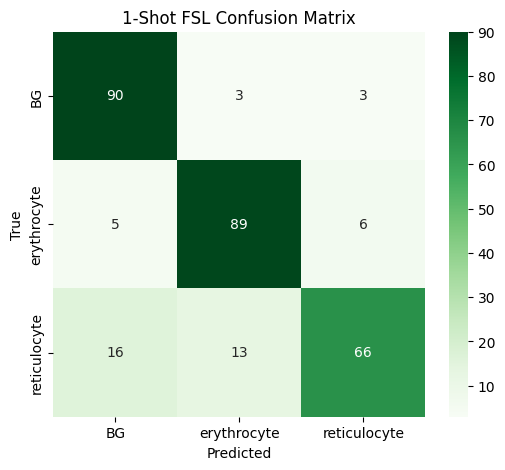


🔹 2-Shot Few-Shot Learning
Few-shot dataset size: 6 (2 per class)
Epoch 1/10 | Loss: 0.9546 | Acc: 83.33%
Epoch 2/10 | Loss: 0.9503 | Acc: 83.33%
Epoch 3/10 | Loss: 0.9421 | Acc: 83.33%
Epoch 4/10 | Loss: 0.9047 | Acc: 83.33%
Epoch 5/10 | Loss: 0.9308 | Acc: 83.33%
Epoch 6/10 | Loss: 0.8926 | Acc: 83.33%
Epoch 7/10 | Loss: 0.9014 | Acc: 83.33%
Epoch 8/10 | Loss: 0.8783 | Acc: 83.33%
Epoch 9/10 | Loss: 0.8772 | Acc: 83.33%
Epoch 10/10 | Loss: 0.8985 | Acc: 83.33%
Test Accuracy: 86.60 | F1-Score: 86.51
              precision    recall  f1-score   support

          BG       0.89      0.91      0.90        96
 erythrocyte       0.84      0.90      0.87       100
reticulocyte       0.87      0.79      0.83        95

    accuracy                           0.87       291
   macro avg       0.87      0.87      0.87       291
weighted avg       0.87      0.87      0.87       291



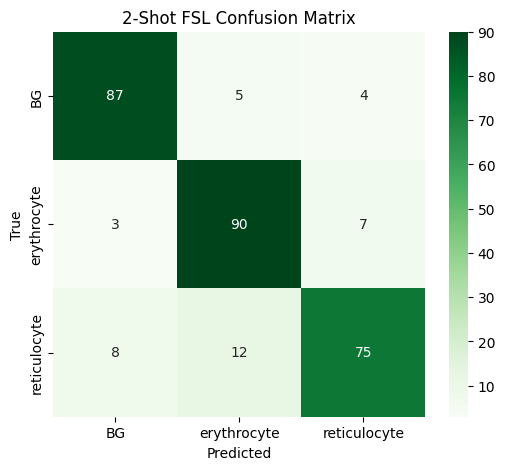


🔹 3-Shot Few-Shot Learning
Few-shot dataset size: 9 (3 per class)
Epoch 1/10 | Loss: 0.9668 | Acc: 88.89%
Epoch 2/10 | Loss: 0.9392 | Acc: 77.78%
Epoch 3/10 | Loss: 0.9225 | Acc: 77.78%
Epoch 4/10 | Loss: 0.9145 | Acc: 77.78%
Epoch 5/10 | Loss: 0.8976 | Acc: 77.78%
Epoch 6/10 | Loss: 0.9032 | Acc: 77.78%
Epoch 7/10 | Loss: 0.9094 | Acc: 77.78%
Epoch 8/10 | Loss: 0.8754 | Acc: 77.78%
Epoch 9/10 | Loss: 0.8907 | Acc: 77.78%
Epoch 10/10 | Loss: 0.8700 | Acc: 77.78%
Test Accuracy: 86.60 | F1-Score: 86.53
              precision    recall  f1-score   support

          BG       0.90      0.91      0.90        96
 erythrocyte       0.85      0.89      0.87       100
reticulocyte       0.85      0.80      0.83        95

    accuracy                           0.87       291
   macro avg       0.87      0.87      0.87       291
weighted avg       0.87      0.87      0.87       291



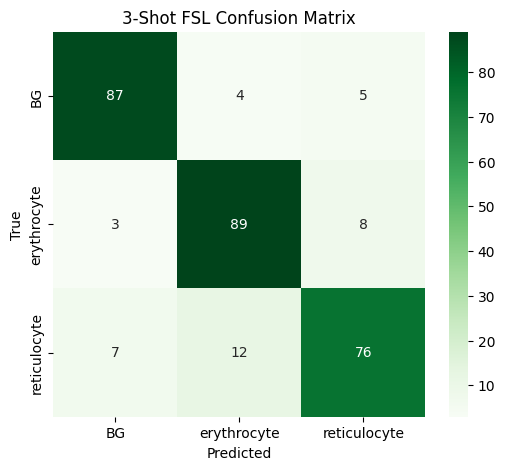


🔹 4-Shot Few-Shot Learning
Few-shot dataset size: 12 (4 per class)
Epoch 1/10 | Loss: 0.9804 | Acc: 66.67%
Epoch 2/10 | Loss: 0.9587 | Acc: 83.33%
Epoch 3/10 | Loss: 0.9554 | Acc: 83.33%
Epoch 4/10 | Loss: 0.9524 | Acc: 75.00%
Epoch 5/10 | Loss: 0.9413 | Acc: 66.67%
Epoch 6/10 | Loss: 0.9548 | Acc: 66.67%
Epoch 7/10 | Loss: 0.9363 | Acc: 83.33%
Epoch 8/10 | Loss: 0.9320 | Acc: 75.00%
Epoch 9/10 | Loss: 0.9153 | Acc: 75.00%
Epoch 10/10 | Loss: 0.9326 | Acc: 75.00%
Test Accuracy: 89.69 | F1-Score: 89.65
              precision    recall  f1-score   support

          BG       0.96      0.89      0.92        96
 erythrocyte       0.86      0.96      0.91       100
reticulocyte       0.89      0.84      0.86        95

    accuracy                           0.90       291
   macro avg       0.90      0.90      0.90       291
weighted avg       0.90      0.90      0.90       291



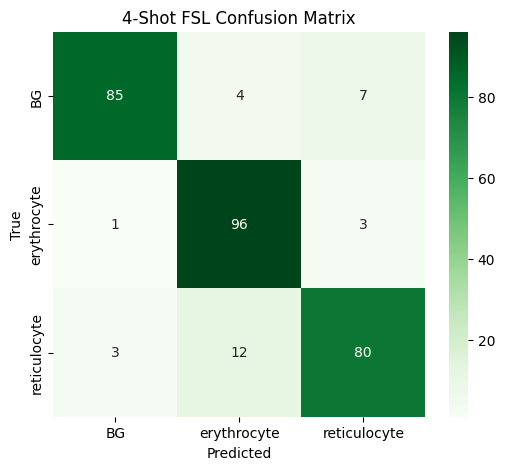


🔹 5-Shot Few-Shot Learning
Few-shot dataset size: 15 (5 per class)
Epoch 1/10 | Loss: 0.9467 | Acc: 80.00%
Epoch 2/10 | Loss: 0.9369 | Acc: 86.67%
Epoch 3/10 | Loss: 0.9416 | Acc: 93.33%
Epoch 4/10 | Loss: 0.9257 | Acc: 80.00%
Epoch 5/10 | Loss: 0.9078 | Acc: 86.67%
Epoch 6/10 | Loss: 0.9247 | Acc: 73.33%
Epoch 7/10 | Loss: 0.9078 | Acc: 93.33%
Epoch 8/10 | Loss: 0.8953 | Acc: 86.67%
Epoch 9/10 | Loss: 0.9001 | Acc: 80.00%
Epoch 10/10 | Loss: 0.8958 | Acc: 80.00%
Test Accuracy: 88.32 | F1-Score: 88.36
              precision    recall  f1-score   support

          BG       0.95      0.86      0.91        96
 erythrocyte       0.83      0.93      0.88       100
reticulocyte       0.88      0.85      0.87        95

    accuracy                           0.88       291
   macro avg       0.89      0.88      0.88       291
weighted avg       0.89      0.88      0.88       291



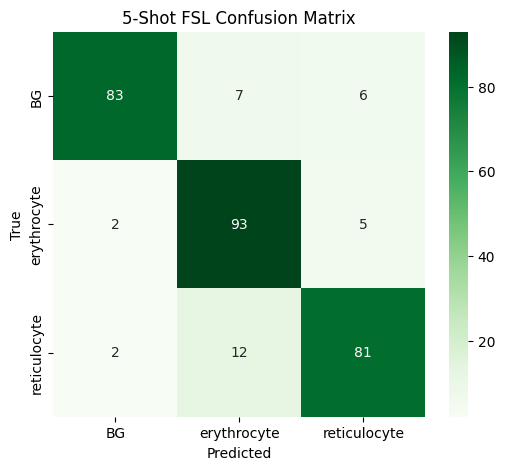

In [3]:
# ====================== FEW-SHOT LEARNING (1 to 5 shots) ======================
import copy
from collections import defaultdict
from torch.utils.data import Subset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== HYPERPARAMETERS ======================
FSL_EPOCHS = 10
FSL_LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ====================== UTILITIES ======================
def create_few_shot_indices(train_dataset, n_shots=5, seed=SEED):
    """Select n_shots per class from a dataset (assumes labels accessible via dataset[idx][1])"""
    np.random.seed(seed)
    class_to_indices = defaultdict(list)
    
    for idx in range(len(train_dataset)):
        _, label = train_dataset[idx]
        class_to_indices[label].append(idx)
    
    few_shot_indices = []
    for label, indices in class_to_indices.items():
        selected = np.random.choice(indices, min(n_shots, len(indices)), replace=False)
        few_shot_indices.extend(selected)
    
    return few_shot_indices

def make_loader(ds, batch_size=32, shuffle=True):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=True)

def freeze_backbone(model):
    """Freeze all layers except final classifier"""
    for name, param in model.named_parameters():
        if 'fc' not in name and 'classifier' not in name:
            param.requires_grad = False
    return model

# ====================== PREPARE FEW-SHOT DATA ======================
# Use the FSL pool ONLY
base_dataset = datasets.ImageFolder(HUMAN_IMG_PATH, transform=train_tf)
fsl_base_dataset = Subset(base_dataset, h_fsl_idx)

# Loop over 1-5 shots
all_reports = {}
for n_shots in range(1, 6):
    print(f"\n🔹 {n_shots}-Shot Few-Shot Learning")
    
    # Select few-shot samples from the FSL pool
    few_shot_indices = create_few_shot_indices(fsl_base_dataset, n_shots=n_shots)
    few_shot_dataset = Subset(fsl_base_dataset, few_shot_indices)
    
    # Apply training transforms
    few_shot_dataset.dataset.transform = train_tf
    few_shot_loader = make_loader(few_shot_dataset)
    
    print(f"Few-shot dataset size: {len(few_shot_dataset)} ({len(few_shot_dataset)//NUM_CLASSES} per class)")
    
    # Clone & freeze student model
    fsl_student = copy.deepcopy(student)
    fsl_student = freeze_backbone(fsl_student).to(DEVICE)
    
    # Setup optimizer, criterion, scheduler
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, fsl_student.parameters()),
        lr=FSL_LR, weight_decay=1e-5
    )
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    # Training loop
    fsl_student.train()
    for epoch in range(FSL_EPOCHS):
        total_loss, correct, total = 0, 0, 0
        for data, target in few_shot_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = fsl_student(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
        
        scheduler.step()
        print(f"Epoch {epoch+1}/{FSL_EPOCHS} | Loss: {total_loss/len(few_shot_loader):.4f} | Acc: {100*correct/total:.2f}%")
    
    # Evaluate on test set
    fsl_acc, fsl_f1, y_true, y_pred = eval_metrics(fsl_student, human_test_loader, return_preds=True)
    print(f"Test Accuracy: {fsl_acc:.2f} | F1-Score: {fsl_f1:.2f}")
    print(classification_report(y_true, y_pred, target_names=human_base.classes))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=human_base.classes,
                yticklabels=human_base.classes)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"{n_shots}-Shot FSL Confusion Matrix")
    plt.show()
    
    # Save results
    all_reports[f"fsl_student_{n_shots}shot"] = {"acc": fsl_acc, "f1": fsl_f1}
    torch.save(fsl_student.state_dict(), SAVE_ROOT / f"fsl_student_{n_shots}shot.pth")


In [4]:
# ====================== GRAD-CAM FOR FSL STUDENT ======================
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        # Forward hook to capture activations
        def forward_hook(module, input, output):
            self.activations = output.detach()

        # Full backward hook to capture gradients
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, x, class_idx=None):
        x = x.requires_grad_(True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        score = logits[:, class_idx]
        self.model.zero_grad()
        score.backward(retain_graph=True)

        if self.gradients is None or self.activations is None:
            raise RuntimeError("Grad-CAM hooks did not capture gradients/activations.")

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = cam.squeeze().cpu().numpy()
        return cam

# Overlay function
def overlay_cam_on_image(img_tensor, cam, alpha=0.5):
    img = img_tensor.cpu().permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255*cam_resized), cv2.COLORMAP_JET)
    heatmap = heatmap[..., ::-1]/255.0  # BGR to RGB
    overlay = (1-alpha)*img + alpha*heatmap
    overlay = np.clip(overlay, 0, 1)
    return overlay

# ====================== RUN GRAD-CAM ======================
target_layer = None
for name, module in fsl_student.named_modules():
    if isinstance(module, nn.Conv2d):
        target_layer = module

if target_layer is None:
    raise ValueError("No Conv2d layer found in the FSL student model!")

print(f"🎯 Using target layer for Grad-CAM: {target_layer}")
gradcam = GradCAM(fsl_student, target_layer)

# Pick some test samples
sample_images, sample_labels = next(iter(human_test_loader))
sample_images, sample_labels = sample_images.to(DEVICE), sample_labels.to(DEVICE)
fsl_student.eval()

# Save Grad-CAMs
os.makedirs(SAVE_ROOT / "gradcam", exist_ok=True)

for i in range(min(10, len(sample_images))):
    img = sample_images[i].unsqueeze(0)
    cam = gradcam(img)
    overlay = overlay_cam_on_image(sample_images[i], cam)

    true_label = human_base.classes[sample_labels[i].item()]
    pred_label = human_base.classes[fsl_student(img).argmax(1).item()]
    status = "correct" if pred_label == true_label else "wrong"

    plt.imsave(SAVE_ROOT / "gradcam" / f"{i}_{status}_true-{true_label}_pred-{pred_label}.png", overlay)

print("✅ Grad-CAMs saved to:", SAVE_ROOT / "gradcam")


🎯 Using target layer for Grad-CAM: Conv2d(192, 1024, kernel_size=(1, 1), stride=(1, 1), bias=False)
✅ Grad-CAMs saved to: outputs/kd_augmented/gradcam


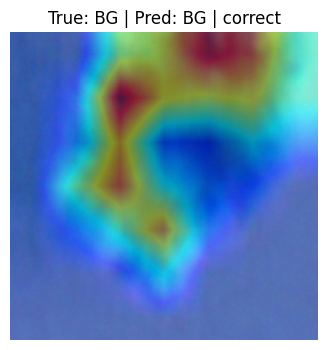

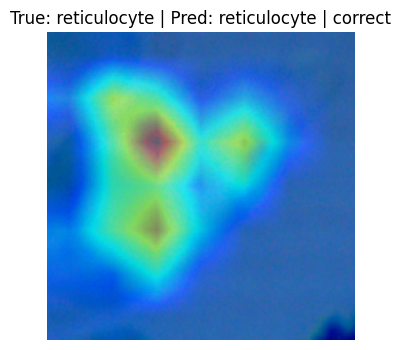

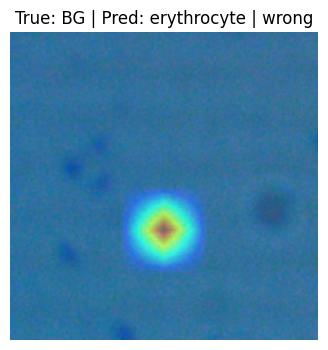

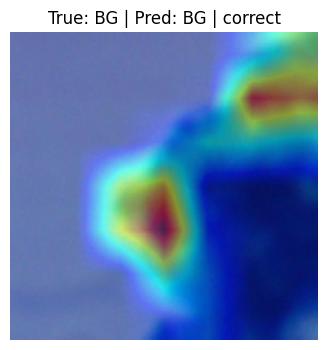

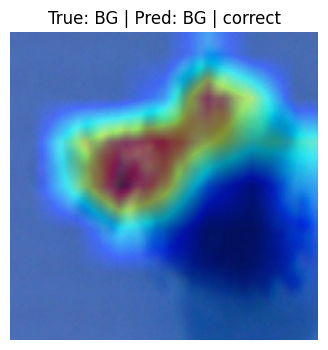

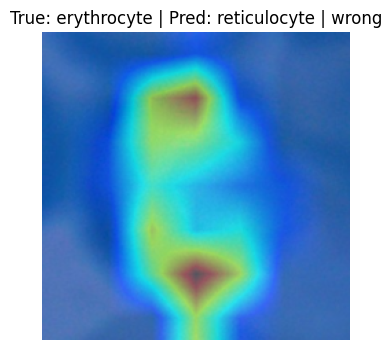

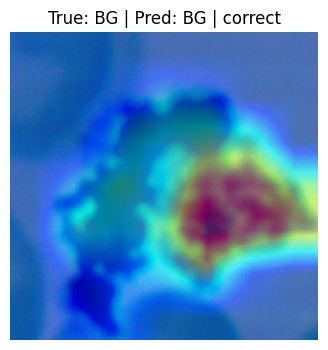

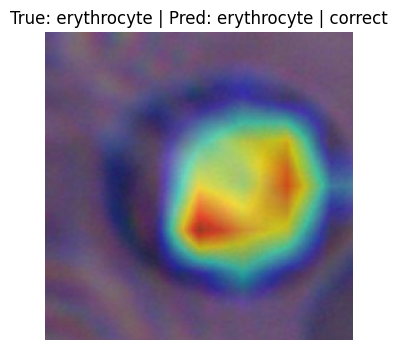

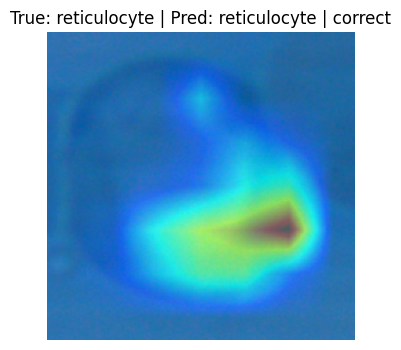

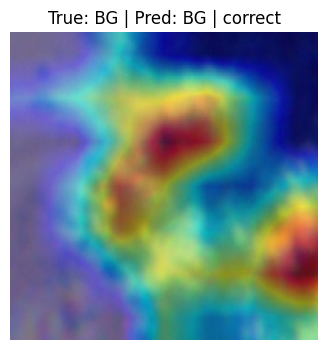

In [5]:
for i in range(min(10, len(sample_images))):
    img = sample_images[i].unsqueeze(0)
    cam = gradcam(img)
    overlay = overlay_cam_on_image(sample_images[i], cam)

    true_label = human_base.classes[sample_labels[i].item()]
    pred_label = human_base.classes[fsl_student(img).argmax(1).item()]
    status = "correct" if pred_label == true_label else "wrong"

    # Display inline
    plt.figure(figsize=(4,4))
    plt.imshow(overlay)
    plt.axis('off')
    plt.title(f"True: {true_label} | Pred: {pred_label} | {status}")
    plt.show()

    # Save to disk
    overlay_uint8 = (overlay * 255).astype(np.uint8)
    plt.imsave(SAVE_ROOT / "gradcam" / f"{i}_{status}_true-{true_label}_pred-{pred_label}.png", overlay_uint8)


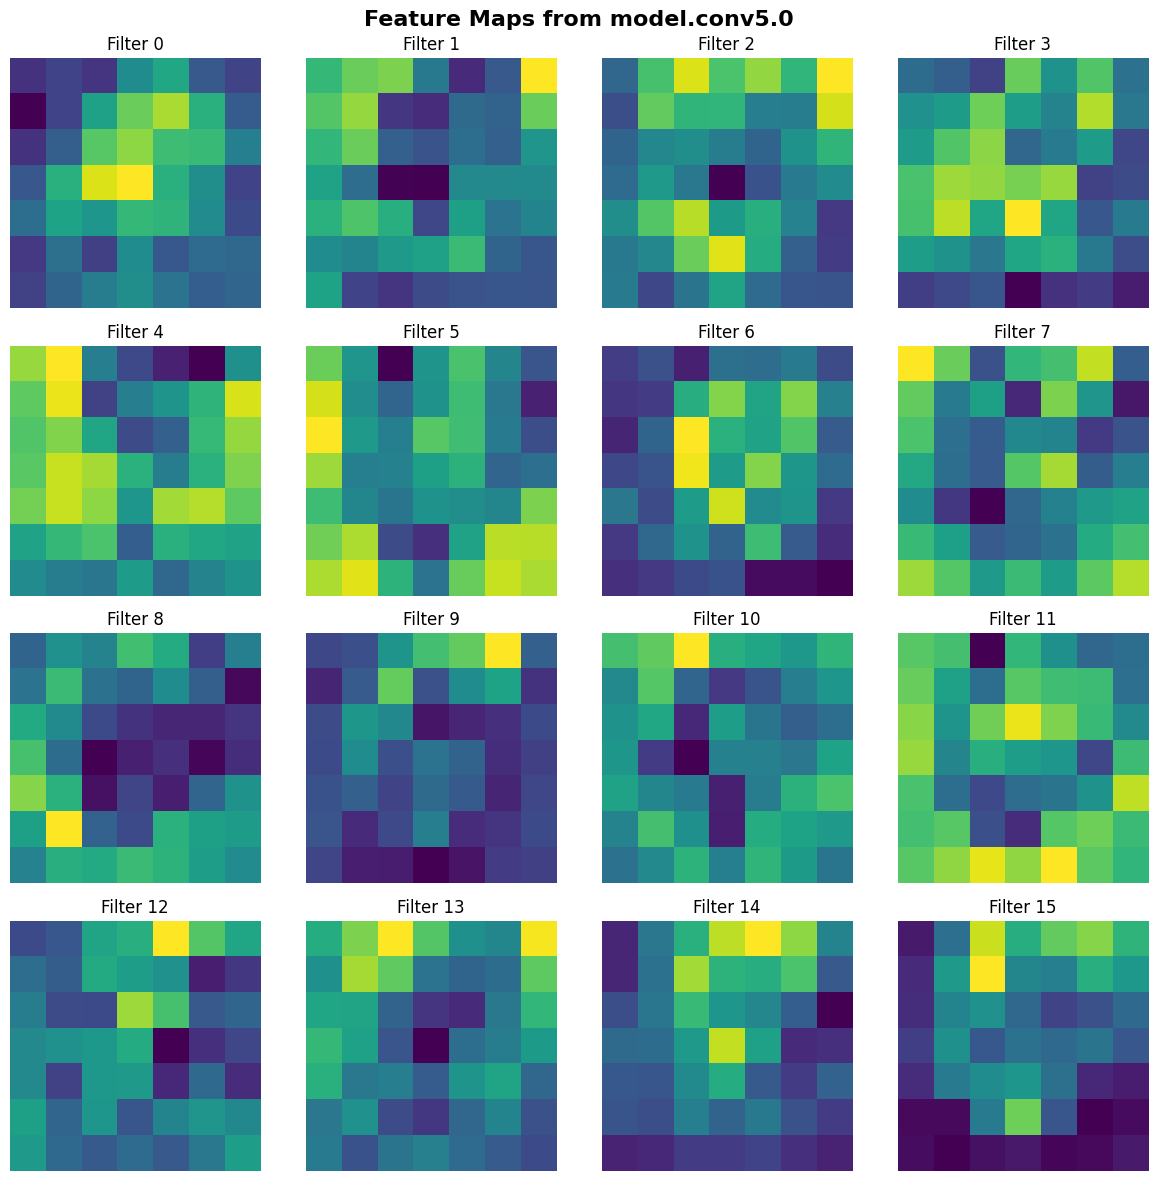

In [6]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

def visualize_feature_maps_auto(model, input_tensor, max_channels=16):
    """
    Visualize feature maps from the last convolutional layer of any PyTorch model.
    Args:
        model: PyTorch model
        input_tensor: input image tensor [B, C, H, W] (batch usually 1)
        max_channels: maximum number of feature maps to display
    """
    model.eval()
    features = {}

    # Find last Conv2d layer automatically
    last_conv = None
    last_conv_name = ""
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
            last_conv_name = name

    if last_conv is None:
        print("No Conv2d layer found in model.")
        return

    # Register hook to capture output of last conv layer
    def hook_fn(module, input, output):
        features['feat'] = output

    handle = last_conv.register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(input_tensor)

    handle.remove()

    if 'feat' not in features:
        print("Hook did not capture features.")
        return

    # Take first image in batch
    feature_maps = features['feat'][0].cpu().numpy()  # shape [C, H, W]
    n_channels = min(max_channels, feature_maps.shape[0])

    # Create grid for plotting
    n_rows = (n_channels + 3) // 4
    n_cols = min(4, n_channels)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    axes = axes.flatten()
    fig.suptitle(f'Feature Maps from {last_conv_name}', fontsize=16, fontweight='bold')

    for i in range(n_channels):
        axes[i].imshow(feature_maps[i], cmap='viridis')
        axes[i].set_title(f'Filter {i}')
        axes[i].axis('off')

    # Turn off remaining axes if n_channels < n_rows*n_cols
    for j in range(n_channels, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Example usage on FSL student
sample_input = next(iter(human_test_loader))[0][:1].to(DEVICE)  # Take first image
visualize_feature_maps_auto(fsl_student, sample_input, max_channels=16)



🔎 Running t-SNE Decision Boundary Analysis for Student...


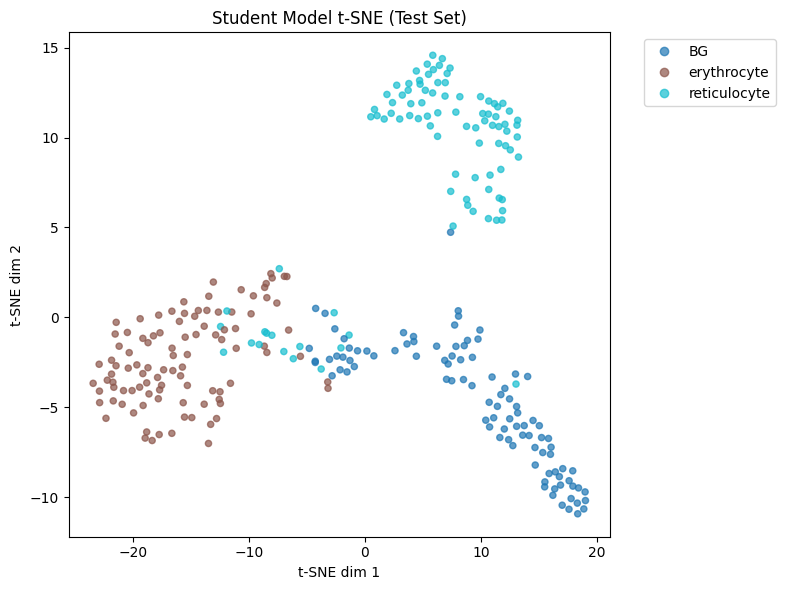

In [7]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

@torch.no_grad()
def extract_features(model, loader):
    model.eval()
    features, labels, preds = [], [], []
    for x, y in loader:
        x = x.to(DEVICE)
        out = model(x)
        # Extract penultimate layer features
        if hasattr(model, "model") and hasattr(model.model, "fc"):  
            feats = model.model.fc[1].weight.cpu().detach().numpy()  # fallback
            # Better way: take logits instead of weights
            feats = out.cpu().numpy()
        else:
            feats = out.cpu().numpy()
        features.append(feats)
        labels.extend(y.numpy().tolist())
        preds.extend(out.argmax(1).cpu().numpy().tolist())
    return np.vstack(features), np.array(labels), np.array(preds)

def tsne_plot(model, loader, title="t-SNE Decision Boundary"):
    feats, labels, preds = extract_features(model, loader)

    # Reduce dimensionality
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
    X_2d = tsne.fit_transform(feats)

    # Plot: True labels vs predicted
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, cmap="tab10", alpha=0.7, s=20)
    plt.legend(handles=scatter.legend_elements()[0],
               labels=human_base.classes,
               bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(title)
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.tight_layout()
    plt.show()

# Example usage
print("\n🔎 Running t-SNE Decision Boundary Analysis for Student...")
tsne_plot(student, human_test_loader, title="Student Model t-SNE (Test Set)")


📊 DETAILED CLASS ANALYSIS


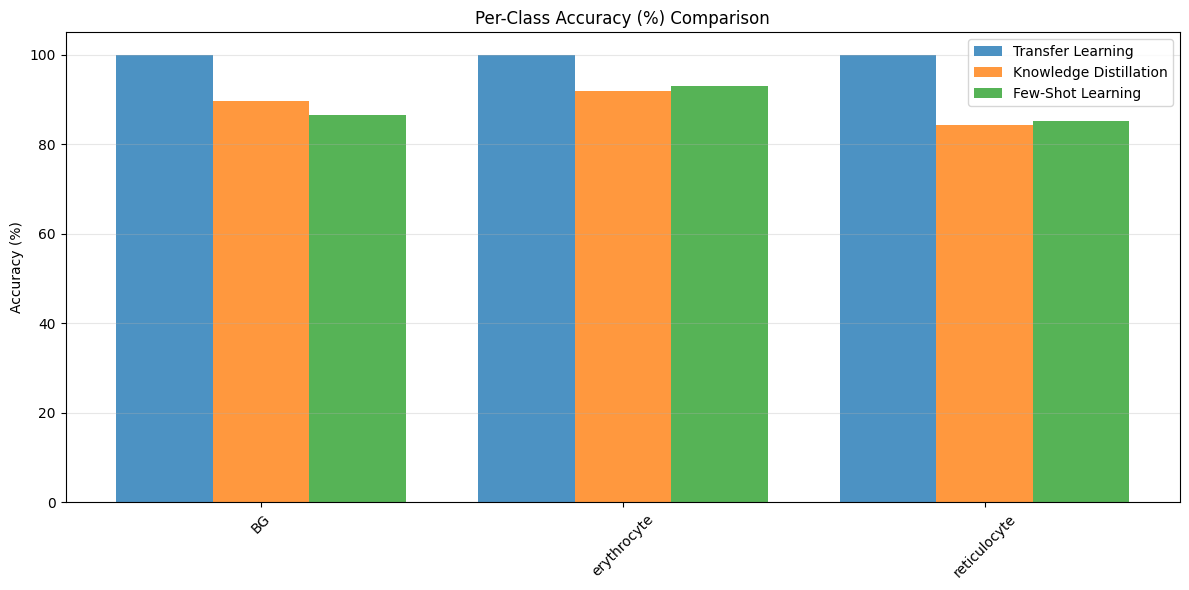

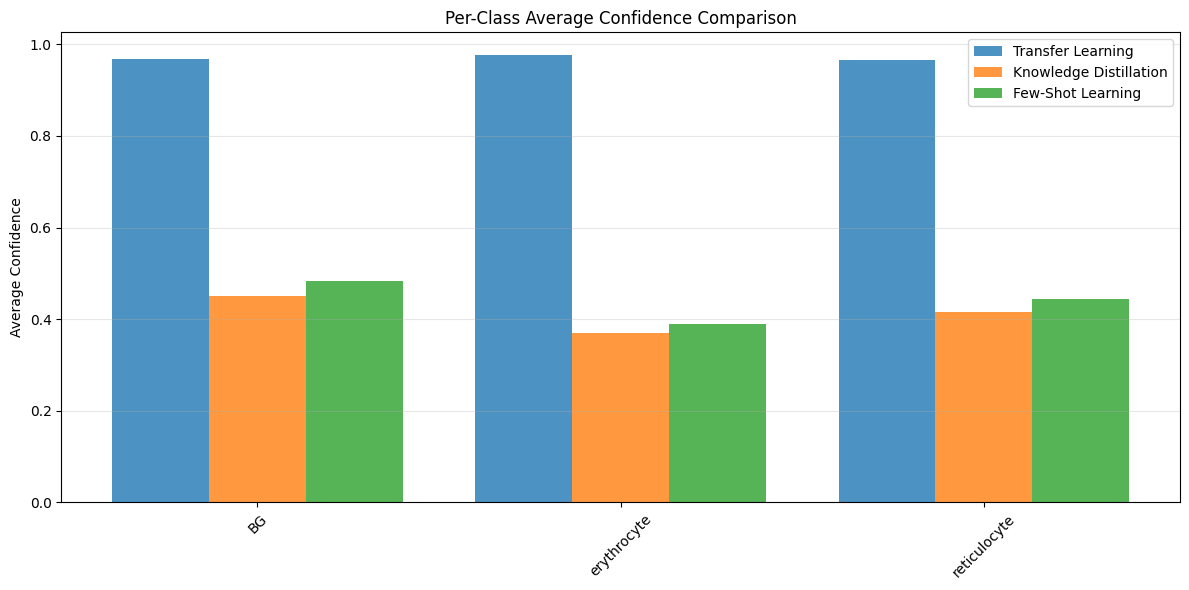

In [8]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Pick one teacher as baseline
human_model = teachers["vgg16_transfer"]

# Make sure class names are available
human_classes = human_base.classes

# For FSL, pick the last trained few-shot model (e.g., 5-shot)
# Save it after the loop:
final_fsl_student = copy.deepcopy(fsl_student)


# ====================== PER-CLASS ANALYSIS ======================
def detailed_class_analysis(model, data_loader, class_names, device=DEVICE):
    """Compute per-class accuracy and confidence statistics for a model."""
    model.eval()
    
    class_correct = {i: 0 for i in range(len(class_names))}
    class_total = {i: 0 for i in range(len(class_names))}
    class_confidence = {i: [] for i in range(len(class_names))}
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            for i in range(labels.size(0)):
                true_label = labels[i].item()
                pred_label = preds[i].item()
                conf = probs[i, pred_label].item()
                
                class_total[true_label] += 1
                class_confidence[true_label].append(conf)
                
                if true_label == pred_label:
                    class_correct[true_label] += 1
    
    # Aggregate results
    results = {}
    for i, cname in enumerate(class_names):
        if class_total[i] > 0:
            results[cname] = {
                "accuracy": 100.0 * class_correct[i] / class_total[i],
                "total_samples": class_total[i],
                "correct_predictions": class_correct[i],
                "avg_confidence": np.mean(class_confidence[i]),
                "std_confidence": np.std(class_confidence[i])
            }
    return results


# ====================== VISUALIZATION ======================
def visualize_class_analysis(results_dict, class_names, metric="accuracy"):
    """
    Compare per-class metrics (accuracy or confidence) across multiple models.
    
    results_dict: { "ModelName": results_from_detailed_class_analysis, ... }
    metric: "accuracy" or "avg_confidence"
    """
    classes = class_names
    x = np.arange(len(classes))
    width = 0.8 / len(results_dict)  # Adjust bar width for multiple models
    
    plt.figure(figsize=(12,6))
    for i, (model_name, res) in enumerate(results_dict.items()):
        values = [res[c][metric] for c in classes]
        plt.bar(x + i*width - (len(results_dict)-1)*width/2, values, width, label=model_name, alpha=0.8)
    
    plt.xticks(x, classes, rotation=45)
    ylabel = "Accuracy (%)" if metric == "accuracy" else "Average Confidence"
    plt.ylabel(ylabel)
    plt.title(f"Per-Class {ylabel} Comparison")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


# ====================== EXAMPLE USAGE ======================
print("📊 DETAILED CLASS ANALYSIS")
print("="*50)

# Run per-class analysis for multiple models
tl_results  = detailed_class_analysis(human_model, human_test_loader, human_classes)
kd_results  = detailed_class_analysis(student, human_test_loader, human_classes)
fsl_results = detailed_class_analysis(fsl_student, human_test_loader, human_classes)

# Compare Accuracy
visualize_class_analysis(
    {"Transfer Learning": tl_results, "Knowledge Distillation": kd_results, "Few-Shot Learning": fsl_results},
    human_classes, metric="accuracy"
)

# Compare Confidence
visualize_class_analysis(
    {"Transfer Learning": tl_results, "Knowledge Distillation": kd_results, "Few-Shot Learning": fsl_results},
    human_classes, metric="avg_confidence"
)



🔹 1-Shot Few-Shot Learning
Few-shot dataset size: 3 (1 per class)
Epoch 1/10 | Loss: 0.9237 | Acc: 100.00%
Epoch 2/10 | Loss: 0.8983 | Acc: 100.00%
Epoch 3/10 | Loss: 0.9277 | Acc: 100.00%
Epoch 4/10 | Loss: 0.9066 | Acc: 100.00%
Epoch 5/10 | Loss: 0.9390 | Acc: 100.00%
Epoch 6/10 | Loss: 0.9096 | Acc: 100.00%
Epoch 7/10 | Loss: 0.8896 | Acc: 100.00%
Epoch 8/10 | Loss: 0.8764 | Acc: 100.00%
Epoch 9/10 | Loss: 0.8860 | Acc: 100.00%
Epoch 10/10 | Loss: 0.8335 | Acc: 100.00%
Test Accuracy: 85.22 | F1-Score: 84.92
              precision    recall  f1-score   support

          BG       0.84      0.94      0.89        96
 erythrocyte       0.86      0.89      0.88       100
reticulocyte       0.85      0.73      0.78        95

    accuracy                           0.85       291
   macro avg       0.85      0.85      0.85       291
weighted avg       0.85      0.85      0.85       291



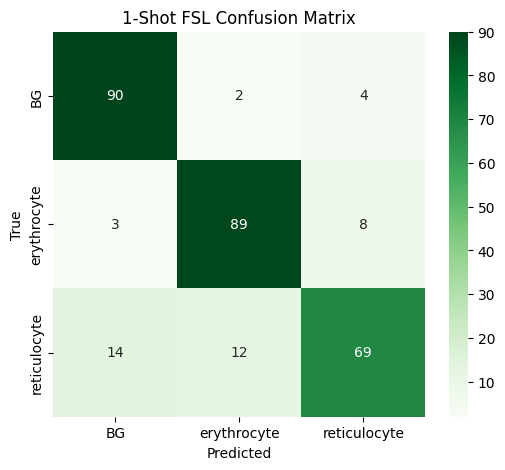


🔹 2-Shot Few-Shot Learning
Few-shot dataset size: 6 (2 per class)
Epoch 1/10 | Loss: 0.9508 | Acc: 83.33%
Epoch 2/10 | Loss: 0.9311 | Acc: 83.33%
Epoch 3/10 | Loss: 0.9272 | Acc: 83.33%
Epoch 4/10 | Loss: 0.9133 | Acc: 83.33%
Epoch 5/10 | Loss: 0.9165 | Acc: 83.33%
Epoch 6/10 | Loss: 0.8938 | Acc: 83.33%
Epoch 7/10 | Loss: 0.8961 | Acc: 83.33%
Epoch 8/10 | Loss: 0.9205 | Acc: 83.33%
Epoch 9/10 | Loss: 0.8949 | Acc: 83.33%
Epoch 10/10 | Loss: 0.9102 | Acc: 83.33%
Test Accuracy: 86.25 | F1-Score: 86.14
              precision    recall  f1-score   support

          BG       0.88      0.91      0.89        96
 erythrocyte       0.84      0.90      0.87       100
reticulocyte       0.87      0.78      0.82        95

    accuracy                           0.86       291
   macro avg       0.86      0.86      0.86       291
weighted avg       0.86      0.86      0.86       291



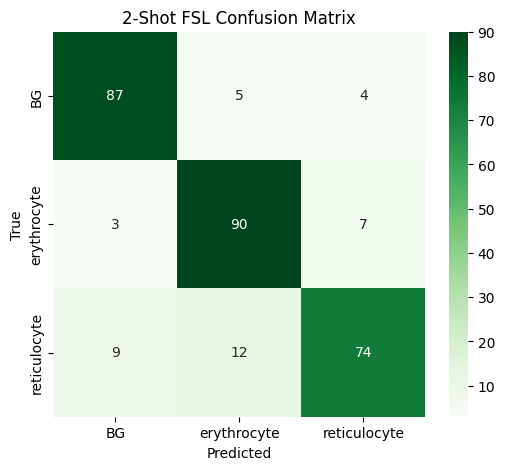


🔹 3-Shot Few-Shot Learning
Few-shot dataset size: 9 (3 per class)
Epoch 1/10 | Loss: 0.9438 | Acc: 77.78%
Epoch 2/10 | Loss: 0.9298 | Acc: 77.78%
Epoch 3/10 | Loss: 0.9239 | Acc: 77.78%
Epoch 4/10 | Loss: 0.9076 | Acc: 77.78%
Epoch 5/10 | Loss: 0.9079 | Acc: 88.89%
Epoch 6/10 | Loss: 0.9083 | Acc: 77.78%
Epoch 7/10 | Loss: 0.8853 | Acc: 88.89%
Epoch 8/10 | Loss: 0.8962 | Acc: 77.78%
Epoch 9/10 | Loss: 0.8732 | Acc: 88.89%
Epoch 10/10 | Loss: 0.8810 | Acc: 77.78%
Test Accuracy: 86.94 | F1-Score: 86.80
              precision    recall  f1-score   support

          BG       0.88      0.92      0.90        96
 erythrocyte       0.85      0.91      0.88       100
reticulocyte       0.88      0.78      0.83        95

    accuracy                           0.87       291
   macro avg       0.87      0.87      0.87       291
weighted avg       0.87      0.87      0.87       291



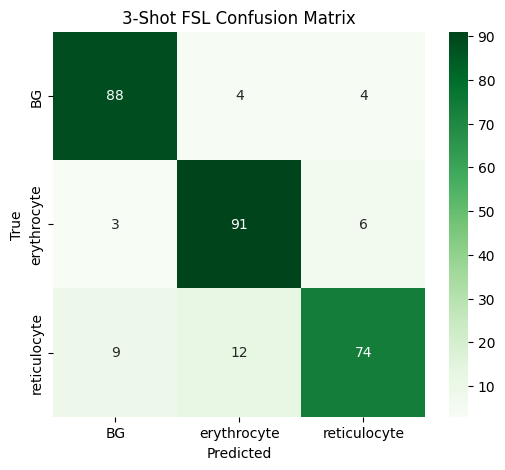


🔹 4-Shot Few-Shot Learning
Few-shot dataset size: 12 (4 per class)
Epoch 1/10 | Loss: 0.9737 | Acc: 75.00%
Epoch 2/10 | Loss: 0.9627 | Acc: 66.67%
Epoch 3/10 | Loss: 0.9600 | Acc: 75.00%
Epoch 4/10 | Loss: 0.9442 | Acc: 83.33%
Epoch 5/10 | Loss: 0.9303 | Acc: 83.33%
Epoch 6/10 | Loss: 0.9312 | Acc: 66.67%
Epoch 7/10 | Loss: 0.9172 | Acc: 75.00%
Epoch 8/10 | Loss: 0.9302 | Acc: 83.33%
Epoch 9/10 | Loss: 0.9258 | Acc: 75.00%
Epoch 10/10 | Loss: 0.9028 | Acc: 75.00%
Test Accuracy: 89.35 | F1-Score: 89.35
              precision    recall  f1-score   support

          BG       0.96      0.89      0.92        96
 erythrocyte       0.85      0.94      0.90       100
reticulocyte       0.88      0.85      0.87        95

    accuracy                           0.89       291
   macro avg       0.90      0.89      0.89       291
weighted avg       0.90      0.89      0.89       291



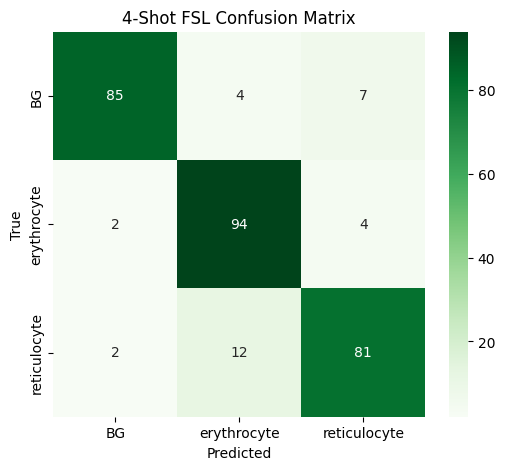


🔹 5-Shot Few-Shot Learning
Few-shot dataset size: 15 (5 per class)
Epoch 1/10 | Loss: 0.9662 | Acc: 80.00%
Epoch 2/10 | Loss: 0.9460 | Acc: 80.00%
Epoch 3/10 | Loss: 0.9236 | Acc: 86.67%
Epoch 4/10 | Loss: 0.9334 | Acc: 80.00%
Epoch 5/10 | Loss: 0.9223 | Acc: 80.00%
Epoch 6/10 | Loss: 0.9031 | Acc: 80.00%
Epoch 7/10 | Loss: 0.9022 | Acc: 80.00%
Epoch 8/10 | Loss: 0.8969 | Acc: 80.00%
Epoch 9/10 | Loss: 0.8931 | Acc: 86.67%
Epoch 10/10 | Loss: 0.8934 | Acc: 86.67%
Test Accuracy: 88.32 | F1-Score: 88.31
              precision    recall  f1-score   support

          BG       0.93      0.89      0.91        96
 erythrocyte       0.84      0.93      0.88       100
reticulocyte       0.89      0.83      0.86        95

    accuracy                           0.88       291
   macro avg       0.89      0.88      0.88       291
weighted avg       0.89      0.88      0.88       291



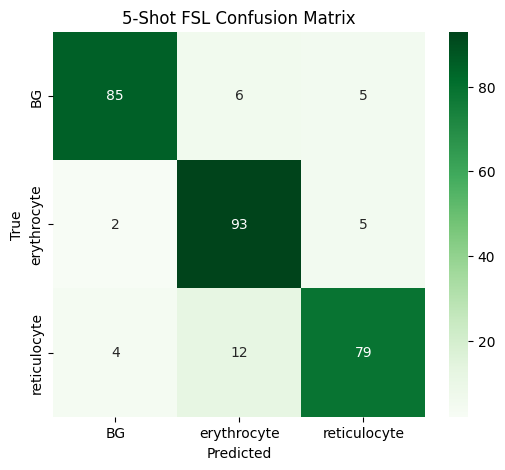

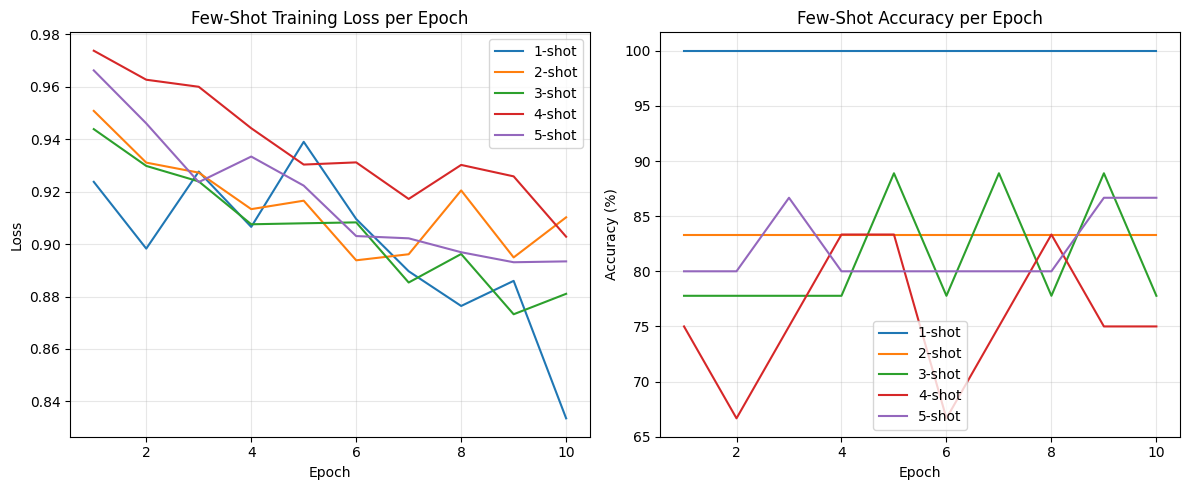

In [9]:
# ====================== FEW-SHOT LEARNING (1 to 5 shots) ======================
import copy
from collections import defaultdict
from torch.utils.data import Subset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# ====================== HYPERPARAMETERS ======================
FSL_EPOCHS = 10
FSL_LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ====================== UTILITIES ======================
def create_few_shot_indices(train_dataset, n_shots=5, seed=SEED):
    """Select n_shots per class from a dataset (assumes labels accessible via dataset[idx][1])"""
    np.random.seed(seed)
    class_to_indices = defaultdict(list)
    for idx in range(len(train_dataset)):
        _, label = train_dataset[idx]
        class_to_indices[label].append(idx)
    
    few_shot_indices = []
    for label, indices in class_to_indices.items():
        selected = np.random.choice(indices, min(n_shots, len(indices)), replace=False)
        few_shot_indices.extend(selected)
    return few_shot_indices

def make_loader(ds, batch_size=32, shuffle=True):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=True)

def freeze_backbone(model):
    """Freeze all layers except final classifier"""
    for name, param in model.named_parameters():
        if 'fc' not in name and 'classifier' not in name:
            param.requires_grad = False
    return model

# ====================== PREPARE FEW-SHOT DATA ======================
base_dataset = datasets.ImageFolder(HUMAN_IMG_PATH, transform=train_tf)
fsl_base_dataset = Subset(base_dataset, h_fsl_idx)

# ====================== TRAINING AND TRACKING ======================
fsl_history = {}  # Store per-epoch loss & accuracy for each n-shot
all_reports = {}

for n_shots in range(1, 6):
    print(f"\n🔹 {n_shots}-Shot Few-Shot Learning")

    # --- Few-shot dataset ---
    few_shot_indices = create_few_shot_indices(fsl_base_dataset, n_shots=n_shots)
    few_shot_dataset = Subset(fsl_base_dataset, few_shot_indices)
    few_shot_dataset.dataset.transform = train_tf
    few_shot_loader = make_loader(few_shot_dataset)

    print(f"Few-shot dataset size: {len(few_shot_dataset)} ({len(few_shot_dataset)//NUM_CLASSES} per class)")

    # --- Clone & freeze student model ---
    fsl_student = copy.deepcopy(student)
    fsl_student = freeze_backbone(fsl_student).to(DEVICE)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, fsl_student.parameters()),
        lr=FSL_LR, weight_decay=1e-5
    )
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    # --- Track metrics ---
    fsl_history[f"{n_shots}-shot"] = {"loss": [], "acc": []}

    # --- Training loop ---
    fsl_student.train()
    for epoch in range(FSL_EPOCHS):
        total_loss, correct, total = 0, 0, 0
        for data, target in few_shot_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = fsl_student(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)

        scheduler.step()
        epoch_loss = total_loss / len(few_shot_loader)
        epoch_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{FSL_EPOCHS} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")

        # Save metrics
        fsl_history[f"{n_shots}-shot"]["loss"].append(epoch_loss)
        fsl_history[f"{n_shots}-shot"]["acc"].append(epoch_acc)

    # --- Evaluate on test set ---
    fsl_acc, fsl_f1, y_true, y_pred = eval_metrics(fsl_student, human_test_loader, return_preds=True)
    print(f"Test Accuracy: {fsl_acc:.2f} | F1-Score: {fsl_f1:.2f}")
    print(classification_report(y_true, y_pred, target_names=human_base.classes))

    # --- Confusion matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=human_base.classes,
                yticklabels=human_base.classes)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"{n_shots}-Shot FSL Confusion Matrix")
    plt.show()

    # --- Save results ---
    all_reports[f"fsl_student_{n_shots}shot"] = {"acc": fsl_acc, "f1": fsl_f1}
    torch.save(fsl_student.state_dict(), SAVE_ROOT / f"fsl_student_{n_shots}shot.pth")

# ====================== VISUALIZE TRAINING CURVES ======================
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
for n_shots in fsl_history:
    plt.plot(range(1, FSL_EPOCHS+1), fsl_history[n_shots]["loss"], label=n_shots)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Few-Shot Training Loss per Epoch")
plt.legend(); plt.grid(True, alpha=0.3)

# Accuracy plot
plt.subplot(1,2,2)
for n_shots in fsl_history:
    plt.plot(range(1, FSL_EPOCHS+1), fsl_history[n_shots]["acc"], label=n_shots)
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.title("Few-Shot Accuracy per Epoch")
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 44.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0

Sample 0 skipped (not reticulocyte, label=0)
Sample 1 skipped (not reticulocyte, label=2)
Sample 2 skipped (not reticulocyte, label=0)
Sample 3 skipped (not reticulocyte, label=0)
Sample 4 skipped (not reticulocyte, label=0)
Sample 5 skipped (not reticulocyte, label=0)
Sample 6 skipped (not reticulocyte, label=0)


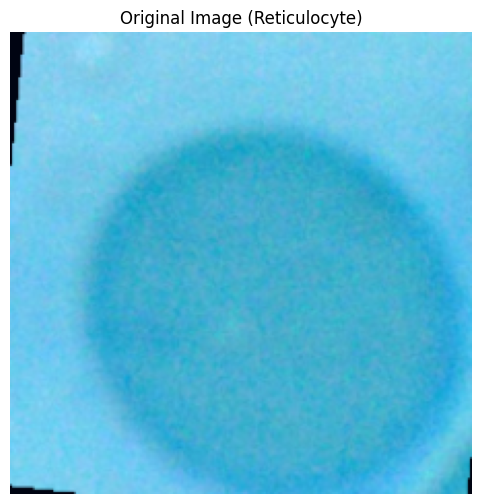

Using last conv layer: model.conv5.0


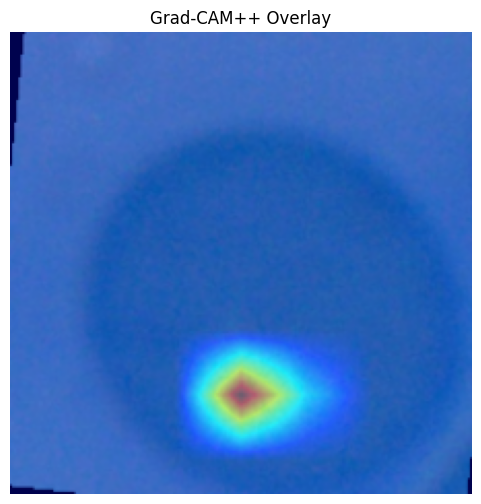

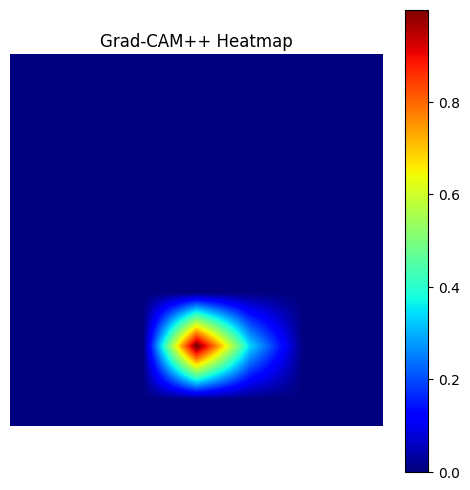

  0%|          | 0/1000 [00:00<?, ?it/s]

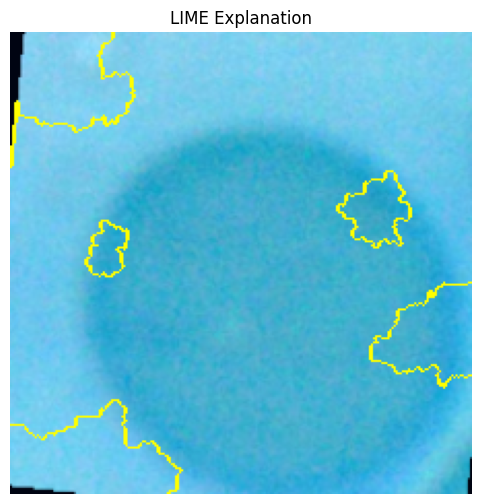

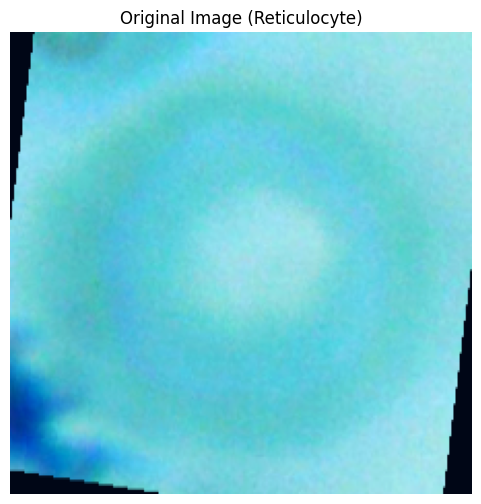

Using last conv layer: model.conv5.0


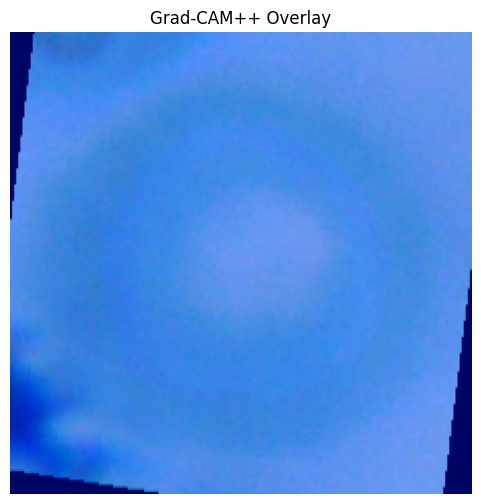

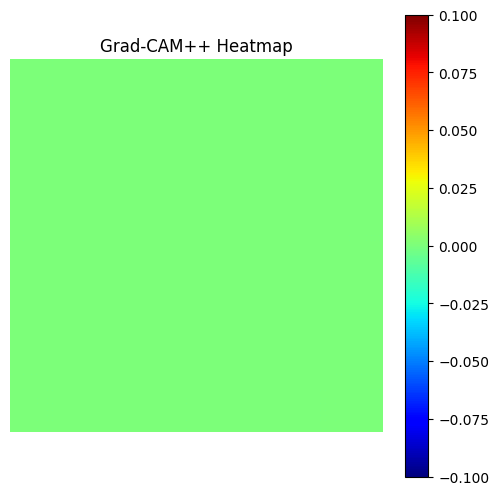

  0%|          | 0/1000 [00:00<?, ?it/s]

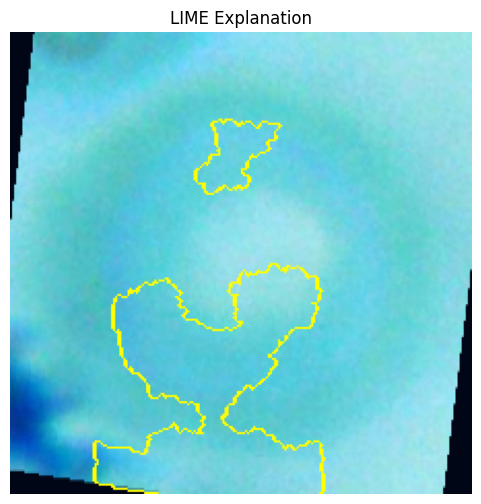

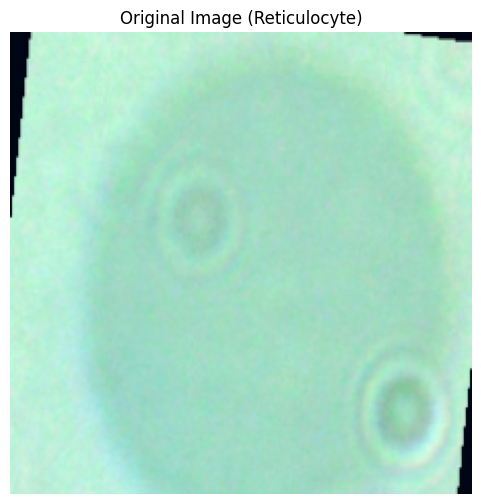

Using last conv layer: model.conv5.0


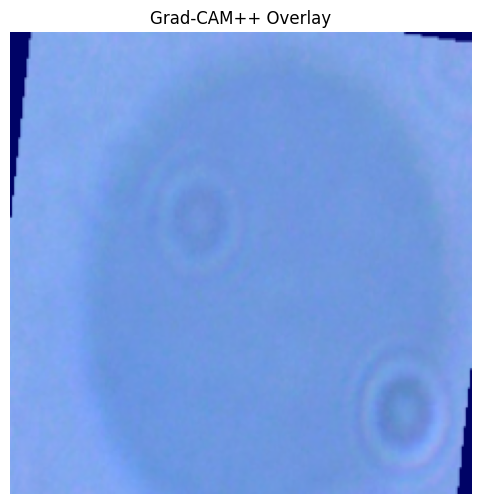

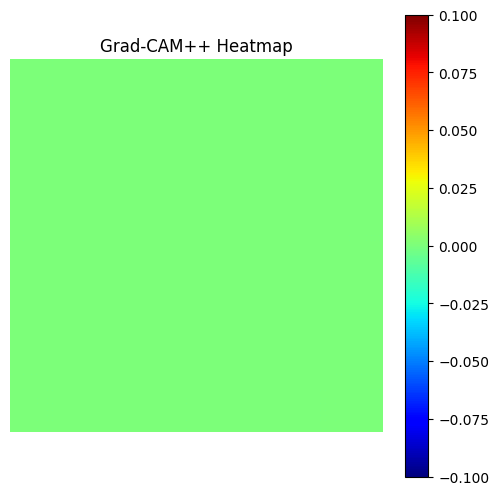

  0%|          | 0/1000 [00:00<?, ?it/s]

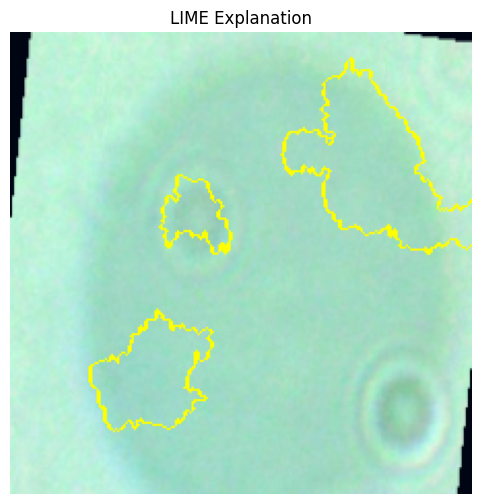

Sample 10 skipped (not reticulocyte, label=2)
Sample 11 skipped (not reticulocyte, label=0)
Sample 12 skipped (not reticulocyte, label=0)
Sample 13 skipped (not reticulocyte, label=0)
Sample 14 skipped (not reticulocyte, label=0)


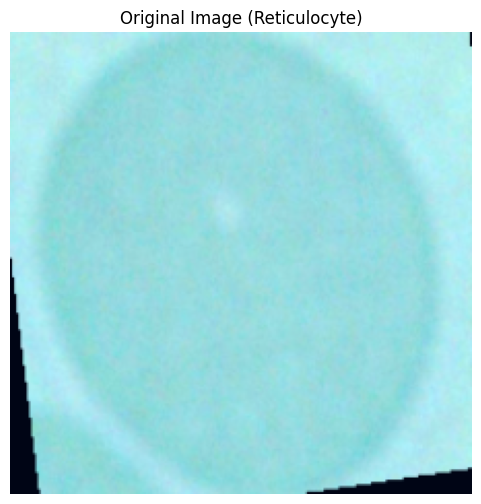

Using last conv layer: model.conv5.0


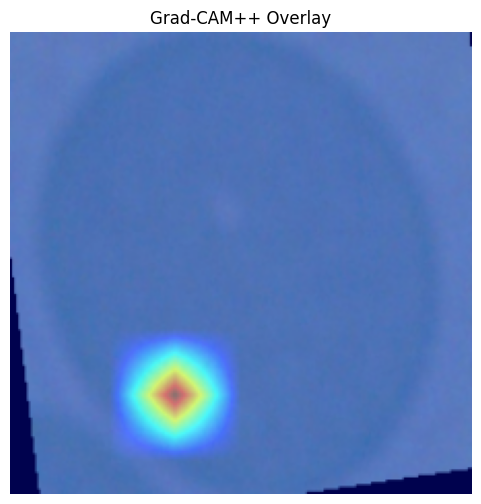

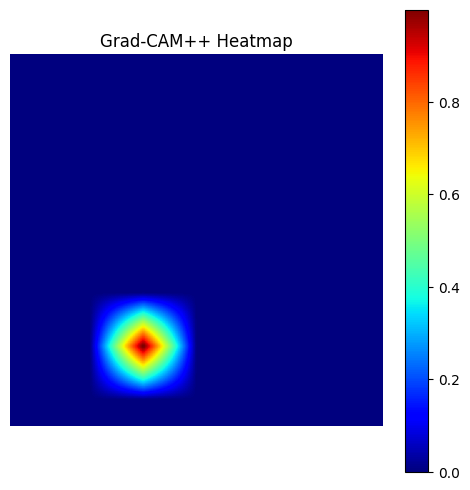

  0%|          | 0/1000 [00:00<?, ?it/s]

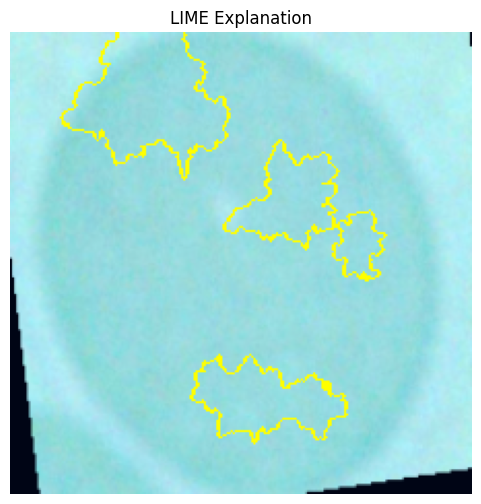

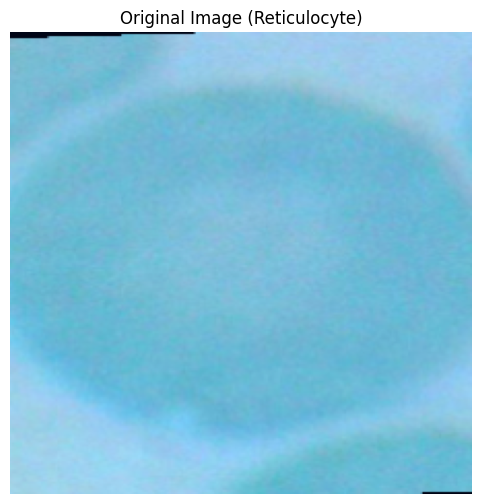

Using last conv layer: model.conv5.0


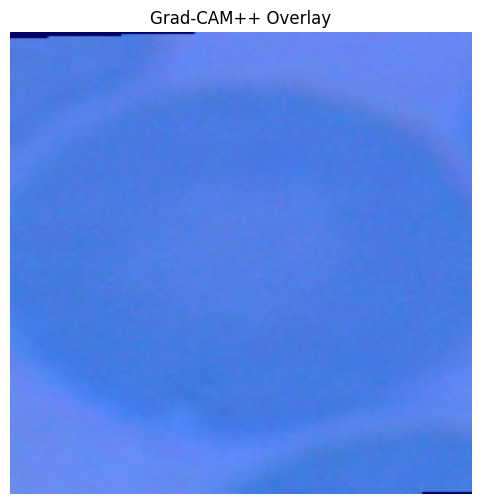

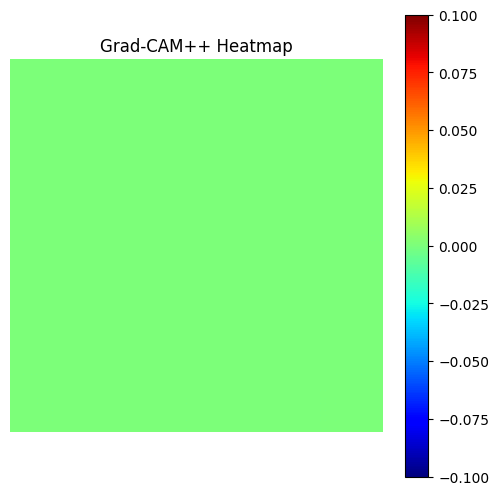

  0%|          | 0/1000 [00:00<?, ?it/s]

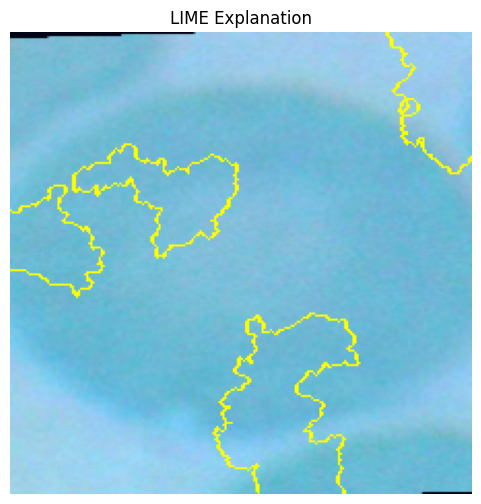

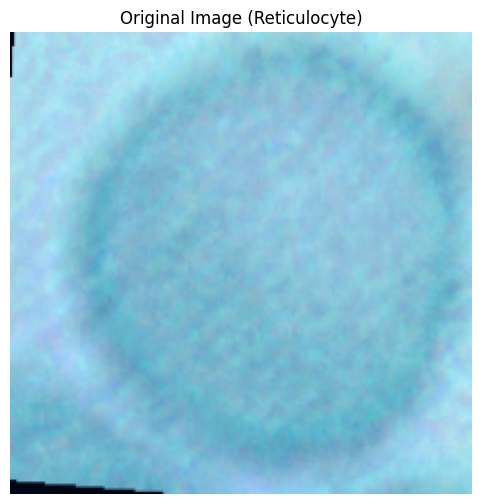

Using last conv layer: model.conv5.0


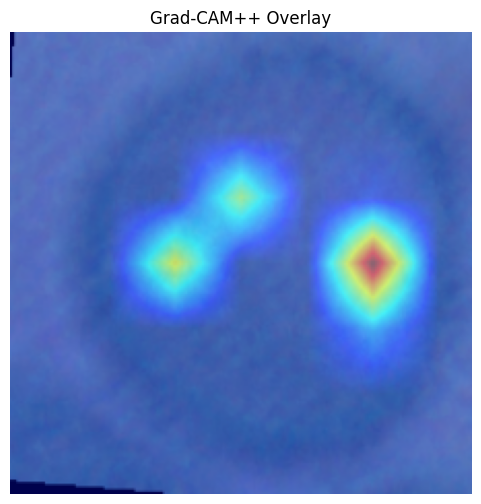

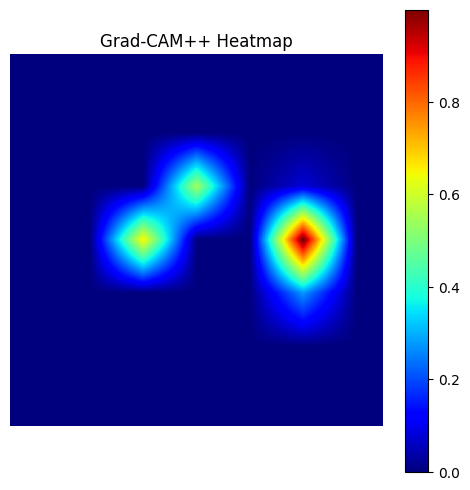

  0%|          | 0/1000 [00:00<?, ?it/s]

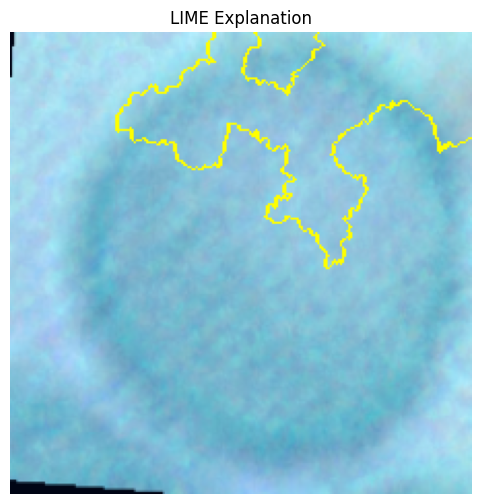

Sample 18 skipped (not reticulocyte, label=0)


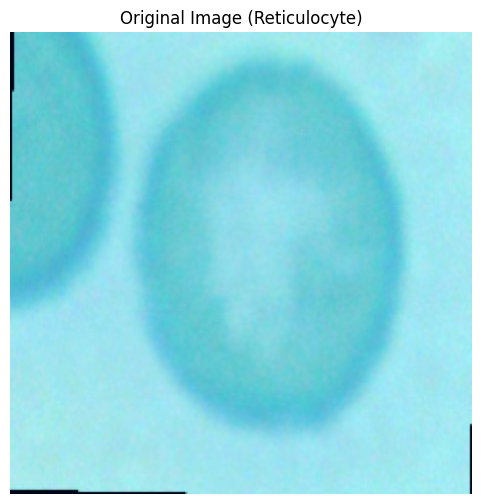

Using last conv layer: model.conv5.0


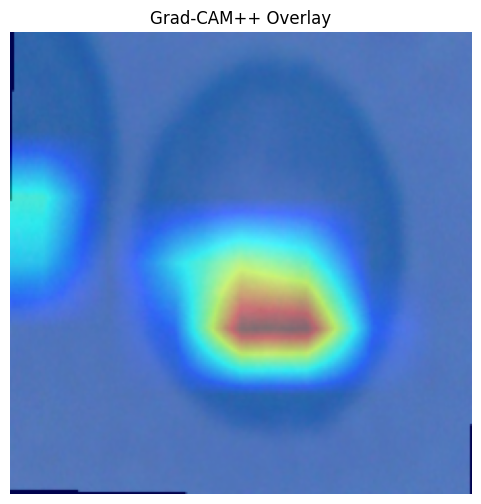

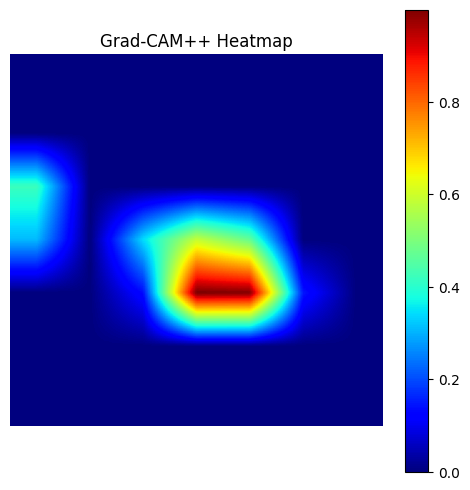

  0%|          | 0/1000 [00:00<?, ?it/s]

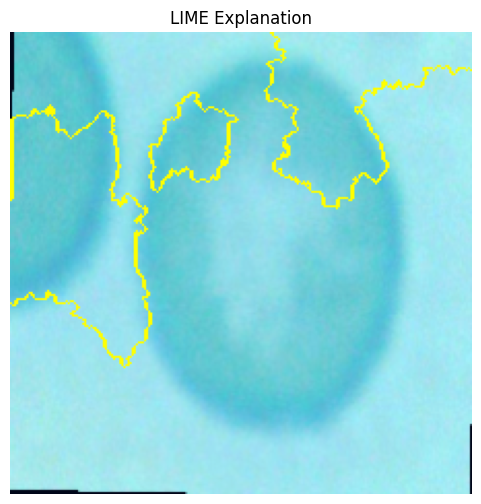

In [12]:
# ====================== IMPORTS ======================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage import img_as_float

# ====================== DEVICE ======================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ====================== UTILITY: FIND LAST CONV ======================
def find_last_conv_layer(model):
    last_conv = None
    last_name = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
            last_name = name
    return last_name, last_conv

# ====================== FUNCTION: VISUALIZE RETICULOCYTES ======================
def visualize_reticulocyte(model, dataset, sample_idx, retic_label=1):
    """
    Visualize a single sample only if it is a reticulocyte.
    Prints Original Image, Grad-CAM++ Overlay, Heatmap, and LIME.
    """
    # Pick sample
    sample_img, sample_label = dataset[sample_idx]

    # Only proceed if label = reticulocyte
    if sample_label != retic_label:
        print(f"Sample {sample_idx} skipped (not reticulocyte, label={sample_label})")
        return

    sample_tensor = sample_img.unsqueeze(0).to(DEVICE)
    sample_tensor.requires_grad = True

    # Convert to numpy for visualization
    img_np = sample_img.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    # Set model to eval
    model.eval()
    
    # ====================== ORIGINAL ======================
    plt.figure(figsize=(6,6))
    plt.imshow(img_np)
    plt.title("Original Image (Reticulocyte)")
    plt.axis('off')
    plt.show()
    
    # ====================== GRAD-CAM++ ======================
    last_conv_name, last_conv_layer = find_last_conv_layer(model)
    print(f"Using last conv layer: {last_conv_name}")

    cam = GradCAMPlusPlus(model=model, target_layers=[last_conv_layer])
    targets = [ClassifierOutputTarget(sample_label)]
    grayscale_cam = cam(input_tensor=sample_tensor, targets=targets)[0]

    # Overlay CAM
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    plt.figure(figsize=(6,6))
    plt.imshow(cam_image)
    plt.title("Grad-CAM++ Overlay")
    plt.axis('off')
    plt.show()

    # Heatmap only
    plt.figure(figsize=(6,6))
    plt.imshow(grayscale_cam, cmap='jet')
    plt.colorbar()
    plt.title("Grad-CAM++ Heatmap")
    plt.axis('off')
    plt.show()

    # ====================== LIME ======================
    def predict_fn(images):
        images = torch.tensor(images.transpose((0,3,1,2)), dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            logits = model(images)
            probs = F.softmax(logits, dim=1)
        return probs.cpu().numpy()

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_np, predict_fn, top_labels=1, hide_color=0, num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    plt.figure(figsize=(6,6))
    plt.imshow(mark_boundaries(img_as_float(temp), mask))
    plt.title("LIME Explanation")
    plt.axis('off')
    plt.show()


# ====================== USAGE ======================
# Example: check first 20 samples and visualize only reticulocytes
for idx in range(20):
    visualize_reticulocyte(fsl_student, fsl_base_dataset, sample_idx=idx, retic_label=1)
